# FlowOpt — Model Validation Notebook
## 05_Validation.ipynb
### Samadhi Santhushee Denagama | st20283341
### Cardiff Metropolitan University / ICBT Campus
### BSc (Hons) Data Science — CSE6035

This notebook performs complete validation of all five FlowOpt 
prediction models including:
- Leave-One-Out Cross-Validation (LOO-CV)
- Performance metrics: MAE, RMSE, R²
- Algorithm comparison: 4 models × 5 tasks
- Residual analysis
- Prediction vs Actual plots
- Final model selection justification

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor)
from sklearn.model_selection import (
    LeaveOneOut, cross_val_score)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score)
import xgboost as xgb

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COLORS = {
    'navy':   '#0B2A4A',
    'teal':   '#0D7377',
    'green':  '#1A9E5C',
    'purple': '#9B59B6',
    'orange': '#E67E22',
    'red':    '#C0392B',
    'light':  '#F4F8FB',
}

BASE      = 'C:/Users/MSI/flowopt'
IMMR_PATH = os.path.join(
    BASE, 'data', 'immr',
    'FlowOpt_IMMR_Complete.xlsx')
AHB_PATH  = os.path.join(
    BASE, 'data', 'immr',
    'FlowOpt_SriLanka_AHB_Data.xlsx')
PROCESSED = os.path.join(
    BASE, 'data', 'processed')
MODELS    = os.path.join(
    BASE, 'models')

os.makedirs(PROCESSED, exist_ok=True)
os.makedirs(MODELS, exist_ok=True)

print("✅ All imports successful")
print(f"Base path: {BASE}")

✅ All imports successful
Base path: C:/Users/MSI/flowopt


In [2]:
# ── Load IMMR ─────────────────────────────────────────
df_immr = pd.read_excel(
    IMMR_PATH,
    sheet_name='1_Annual_Totals',
    skiprows=1)
df_immr.columns = (
    df_immr.columns.str.strip())
df_immr = df_immr[
    pd.to_numeric(
        df_immr['Year'],
        errors='coerce').notna()]
df_immr['Year'] = (
    df_immr['Year'].astype(int))
df_immr = df_immr[
    (df_immr['Year'] >= 2013) &
    (df_immr['Year'] <= 2024)].copy()
df_immr = df_immr.rename(columns={
    'Year':             'year',
    'Total Inpatients': 'inpat',
    'Disc TOTAL':       'disc_t',
    'Deaths TOTAL':     'death_t',
})
for col in ['inpat','disc_t','death_t']:
    df_immr[col] = pd.to_numeric(
        df_immr[col], errors='coerce')
df_immr = df_immr.dropna(
    subset=['inpat','disc_t','death_t'])
df_immr = df_immr.sort_values(
    'year').reset_index(drop=True)

print("✅ IMMR loaded:", df_immr.shape)
print(df_immr[['year','inpat',
    'disc_t','death_t']])
print()

# ── Load AHB Bed Occupancy ────────────────────────────
df_bor_raw = pd.read_excel(
    AHB_PATH,
    sheet_name='2_Bed_Occupancy',
    skiprows=1)
df_bor_raw.columns = (
    df_bor_raw.columns.str.strip())
df_bor_raw = df_bor_raw[
    pd.to_numeric(
        df_bor_raw['Year'],
        errors='coerce').notna()]
df_bor_raw['Year'] = (
    df_bor_raw['Year'].astype(int))
df_bor_raw = df_bor_raw[
    (df_bor_raw['Year'] >= 2013) &
    (df_bor_raw['Year'] <= 2024)].copy()
df_bor_raw = df_bor_raw.rename(columns={
    'Year': 'year',
    'Total Hospital Beds': 'beds',
    'Bed Occupancy Rate (BOR) %': 'bor',
    'Average Duration of Stay '
    '(ADOS) Days': 'ados',
})
for col in ['beds','bor','ados']:
    df_bor_raw[col] = pd.to_numeric(
        df_bor_raw[col], errors='coerce')
df_bor_raw = df_bor_raw.dropna(
    subset=['beds','bor','ados'])
df_bor_raw = df_bor_raw.sort_values(
    'year').reset_index(drop=True)

print("✅ BOR/ADOS data loaded:",
    df_bor_raw.shape)
print(df_bor_raw[['year','bor',
    'ados','beds']])
print()

# ── Load AHB OPD Attendance ───────────────────────────
df_opd_raw = pd.read_excel(
    AHB_PATH,
    sheet_name='3_OPD_Attendance',
    skiprows=1)
df_opd_raw.columns = (
    df_opd_raw.columns.str.strip())
df_opd_raw = df_opd_raw[
    pd.to_numeric(
        df_opd_raw['Year'],
        errors='coerce').notna()]
df_opd_raw['Year'] = (
    df_opd_raw['Year'].astype(int))
df_opd_raw = df_opd_raw[
    (df_opd_raw['Year'] >= 2013) &
    (df_opd_raw['Year'] <= 2024)].copy()
df_opd_raw = df_opd_raw.rename(columns={
    'Year': 'year',
    'Total OPD Visits '
    '(All Hospitals)': 'opd',
})
df_opd_raw['opd'] = pd.to_numeric(
    df_opd_raw['opd'], errors='coerce')
df_opd_raw = df_opd_raw.dropna(
    subset=['opd'])
df_opd_raw = df_opd_raw.sort_values(
    'year').reset_index(drop=True)

print("✅ OPD data loaded:",
    df_opd_raw.shape)
print(df_opd_raw[['year','opd']])

✅ IMMR loaded: (12, 11)
    year      inpat     disc_t  death_t
0   2013  5926125.0  5881886.0  44239.0
1   2014  6120470.0  6073053.0  47417.0
2   2015  6359681.0  6311873.0  47808.0
3   2016  6497773.0  6449753.0  48020.0
4   2017  6910249.0  6857911.0  52338.0
5   2018  7116268.0  7063097.0  53171.0
6   2019  7477860.0  7418884.0  58976.0
7   2020  5785147.0  5737317.0  47830.0
8   2021  5314193.0  5250335.0  63858.0
9   2022  6350347.0  6283849.0  66498.0
10  2023  6949732.0  6882377.0  67355.0
11  2024  7194899.0  7126598.0  68301.0

✅ BOR/ADOS data loaded: (12, 6)
    year   bor  ados     beds
0   2013  72.1   3.9  83275.0
1   2014  72.5   3.7  84728.0
2   2015  73.2   3.6  84728.0
3   2016  74.1   3.6  86589.0
4   2017  75.0   3.5  86589.0
5   2018  76.2   3.5  87280.0
6   2019  77.1   3.5  87280.0
7   2020  48.4   3.1  87280.0
8   2021  60.2   3.3  88500.0
9   2022  68.5   3.4  89500.0
10  2023  71.0   3.4  90500.0
11  2024  72.5   3.3  91159.0

✅ OPD data loaded: (12, 7)
    y

In [3]:
# ── Task 1: Inpatient Admissions ──────────────────────
d1 = df_immr[['year','inpat',
    'disc_t','death_t']].copy()
d1['inpat_lag1']  = d1['inpat'].shift(1)
d1['disc_lag1']   = d1['disc_t'].shift(1)
d1['death_lag1']  = d1['death_t'].shift(1)
d1['growth'] = (
    d1['inpat'].pct_change() * 100)
d1['covid'] = d1['year'].apply(
    lambda x: 1
    if x in [2020,2021] else 0)
d1 = d1.dropna()

X_adm = d1[['inpat_lag1','disc_lag1',
    'death_lag1','disc_t',
    'death_t','growth','covid']]
y_adm = d1['inpat']
years_adm = d1['year'].values

print("Task 1 — Inpatient Admissions")
print(f"  Observations: {len(y_adm)}")
print(f"  Features: {list(X_adm.columns)}")
print()

# ── Task 2: Bed Occupancy Rate ────────────────────────
d2 = df_bor_raw[['year','bor',
    'beds']].copy()
d2['bor_lag1']    = d2['bor'].shift(1)
d2['beds_lag1']   = d2['beds'].shift(1)
d2['bor_growth']  = d2['bor'].diff()
d2['covid'] = d2['year'].apply(
    lambda x: 1
    if x in [2020,2021] else 0)
d2 = d2.dropna()

X_bor = d2[['bor_lag1','beds_lag1',
    'beds','bor_growth','covid']]
y_bor = d2['bor']
years_bor = d2['year'].values

print("Task 2 — Bed Occupancy Rate")
print(f"  Observations: {len(y_bor)}")
print(f"  Features: {list(X_bor.columns)}")
print()

# ── Task 3: Avg Length of Stay ────────────────────────
d3 = df_bor_raw[['year','ados',
    'bor']].copy()
d3['ados_lag1']   = d3['ados'].shift(1)
d3['bor_lag1']    = d3['bor'].shift(1)
d3['ados_growth'] = d3['ados'].diff()
d3['covid'] = d3['year'].apply(
    lambda x: 1
    if x in [2020,2021] else 0)
d3 = d3.dropna()

X_ados = d3[['ados_lag1','bor_lag1',
    'bor','ados_growth','covid']]
y_ados = d3['ados']
years_ados = d3['year'].values

print("Task 3 — Avg Length of Stay")
print(f"  Observations: {len(y_ados)}")
print(f"  Features: {list(X_ados.columns)}")
print()

# ── Task 4: OPD Attendance ────────────────────────────
d4 = df_opd_raw[['year','opd']].copy()
d4['opd_lag1'] = d4['opd'].shift(1)
d4['growth'] = (
    d4['opd'].pct_change() * 100)
d4['covid'] = d4['year'].apply(
    lambda x: 1
    if x in [2020,2021] else 0)
d4 = d4.dropna()

X_opd = d4[['opd_lag1','growth','covid']]
y_opd = d4['opd']
years_opd = d4['year'].values

print("Task 4 — OPD Attendance")
print(f"  Observations: {len(y_opd)}")
print(f"  Features: {list(X_opd.columns)}")
print()

# ── Task 5: Discharge Volume ──────────────────────────
d5 = df_immr[['year','disc_t',
    'inpat','death_t']].copy()
d5['disc_lag1']  = d5['disc_t'].shift(1)
d5['inpat_lag1'] = d5['inpat'].shift(1)
d5['death_lag1'] = d5['death_t'].shift(1)
d5['growth'] = (
    d5['inpat'].pct_change() * 100)
d5['covid'] = d5['year'].apply(
    lambda x: 1
    if x in [2020,2021] else 0)
d5 = d5.dropna()

X_disc = d5[['inpat_lag1','disc_lag1',
    'death_lag1','inpat',
    'death_t','growth','covid']]
y_disc = d5['disc_t']
years_disc = d5['year'].values

print("Task 5 — Discharge Volume")
print(f"  Observations: {len(y_disc)}")
print(f"  Features: {list(X_disc.columns)}")
print()
print("✅ All 5 datasets ready!")

Task 1 — Inpatient Admissions
  Observations: 11
  Features: ['inpat_lag1', 'disc_lag1', 'death_lag1', 'disc_t', 'death_t', 'growth', 'covid']

Task 2 — Bed Occupancy Rate
  Observations: 11
  Features: ['bor_lag1', 'beds_lag1', 'beds', 'bor_growth', 'covid']

Task 3 — Avg Length of Stay
  Observations: 11
  Features: ['ados_lag1', 'bor_lag1', 'bor', 'ados_growth', 'covid']

Task 4 — OPD Attendance
  Observations: 11
  Features: ['opd_lag1', 'growth', 'covid']

Task 5 — Discharge Volume
  Observations: 11
  Features: ['inpat_lag1', 'disc_lag1', 'death_lag1', 'inpat', 'death_t', 'growth', 'covid']

✅ All 5 datasets ready!


In [4]:
def evaluate_all_models(X, y,
    task_name, unit=''):
    models = {
        'Linear Regression':
            LinearRegression(),
        'Random Forest':
            RandomForestRegressor(
                n_estimators=50,
                max_depth=2,
                random_state=42),
        'XGBoost':
            xgb.XGBRegressor(
                n_estimators=50,
                max_depth=2,
                learning_rate=0.1,
                random_state=42,
                verbosity=0),
        'Gradient Boosting':
            GradientBoostingRegressor(
                n_estimators=50,
                max_depth=2,
                learning_rate=0.1,
                random_state=42),
    }

    loo = LeaveOneOut()
    results = []

    for name, model in models.items():
        mae_scores = -cross_val_score(
            model, X, y, cv=loo,
            scoring=
                'neg_mean_absolute_error')
        rmse_scores = np.sqrt(
            -cross_val_score(
                model, X, y, cv=loo,
                scoring=
                    'neg_mean_squared_error'))
        r2_scores = cross_val_score(
            model, X, y, cv=loo,
            scoring='r2')

        model.fit(X, y)
        y_pred = model.predict(X)
        full_r2  = r2_score(y, y_pred)
        full_mae = mean_absolute_error(
            y, y_pred)
        full_rmse = np.sqrt(
            mean_squared_error(y, y_pred))

        results.append({
            'Algorithm':   name,
            'LOO-CV MAE':  mae_scores.mean(),
            'LOO-CV RMSE': rmse_scores.mean(),
            'LOO-CV R²':   r2_scores.mean(),
            'Full R²':     full_r2,
            'Full MAE':    full_mae,
            'Full RMSE':   full_rmse,
        })

    df_r = pd.DataFrame(results)
    df_r = df_r.sort_values('LOO-CV MAE')

    print(f"\n{'='*55}")
    print(f"  {task_name}")
    print(f"{'='*55}")
    print(df_r[[
        'Algorithm',
        'LOO-CV MAE',
        'LOO-CV R²',
        'Full R²']].to_string(index=False))
    best = df_r.iloc[0]['Algorithm']
    best_mae = df_r.iloc[0]['LOO-CV MAE']
    print(f"\n  🏆 Best: {best}")
    print(f"     LOO-CV MAE: "
          f"{best_mae:.4f} {unit}")

    return df_r

print("✅ Evaluation function ready")

✅ Evaluation function ready


In [5]:
print("Running LOO-CV — all 5 tasks...")
print("Please wait 1-2 minutes...\n")

r_adm = evaluate_all_models(
    X_adm, y_adm,
    "Task 1: Total Inpatient Admissions",
    "patients")

r_bor = evaluate_all_models(
    X_bor, y_bor,
    "Task 2: Bed Occupancy Rate",
    "%")

r_ados = evaluate_all_models(
    X_ados, y_ados,
    "Task 3: Avg Length of Stay",
    "days")

r_opd = evaluate_all_models(
    X_opd, y_opd,
    "Task 4: OPD Attendance",
    "visits")

r_disc = evaluate_all_models(
    X_disc, y_disc,
    "Task 5: Discharge Volume",
    "patients")

print("\n✅ LOO-CV complete — all 5 tasks!")

Running LOO-CV — all 5 tasks...
Please wait 1-2 minutes...


  Task 1: Total Inpatient Admissions
        Algorithm    LOO-CV MAE  LOO-CV R²  Full R²
Linear Regression      0.000218        NaN 1.000000
Gradient Boosting 166065.903826        NaN 0.999926
    Random Forest 253112.575169        NaN 0.938114
          XGBoost 343440.363636        NaN 0.995865

  🏆 Best: Linear Regression
     LOO-CV MAE: 0.0002 patients

  Task 2: Bed Occupancy Rate
        Algorithm   LOO-CV MAE  LOO-CV R²  Full R²
Linear Regression 3.895066e-13        NaN 1.000000
Gradient Boosting 3.733297e+00        NaN 0.999713
    Random Forest 3.961641e+00        NaN 0.912950
          XGBoost 4.482022e+00        NaN 0.993883

  🏆 Best: Linear Regression
     LOO-CV MAE: 0.0000 %

  Task 3: Avg Length of Stay
        Algorithm   LOO-CV MAE  LOO-CV R²  Full R²
Linear Regression 1.251524e-15        NaN 1.000000
    Random Forest 1.249203e-01        NaN 0.812725
Gradient Boosting 1.262641e-01        NaN 0.998831
      

In [6]:
def get_mae(df_r, algo):
    return df_r[
        df_r['Algorithm']==algo][
        'LOO-CV MAE'].values[0]

algos = [
    'Linear Regression',
    'Random Forest',
    'XGBoost',
    'Gradient Boosting',
]
tasks = [
    'Total Inpatient Admissions',
    'Bed Occupancy Rate (%)',
    'Avg Length of Stay (days)',
    'OPD Attendance',
    'Discharge Volume',
]
results_list = [
    r_adm, r_bor,
    r_ados, r_opd, r_disc,
]

rows = []
for task, r in zip(tasks, results_list):
    row = {'Task': task}
    for a in algos:
        row[a] = round(get_mae(r, a), 4)
    row['Best'] = 'Linear Regression'
    rows.append(row)

df_summary = pd.DataFrame(rows)

print("TABLE 1 — LOO-CV MAE Comparison")
print("All 4 Algorithms × All 5 Tasks")
print("="*80)
print(df_summary.to_string(index=False))
print()
print("🏆 Linear Regression is BEST "
      "for all 5 tasks")

TABLE 1 — LOO-CV MAE Comparison
All 4 Algorithms × All 5 Tasks
                      Task  Linear Regression  Random Forest      XGBoost  Gradient Boosting              Best
Total Inpatient Admissions             0.0002    253112.5752  343440.3636        166065.9038 Linear Regression
    Bed Occupancy Rate (%)             0.0000         3.9616       4.4820             3.7333 Linear Regression
 Avg Length of Stay (days)             0.0000         0.1249       0.1306             0.1263 Linear Regression
            OPD Attendance       1062809.7486   2243709.1657 1977597.7273       2034103.9484 Linear Regression
          Discharge Volume             0.0002    250667.4329  345560.9091        157077.8293 Linear Regression

🏆 Linear Regression is BEST for all 5 tasks


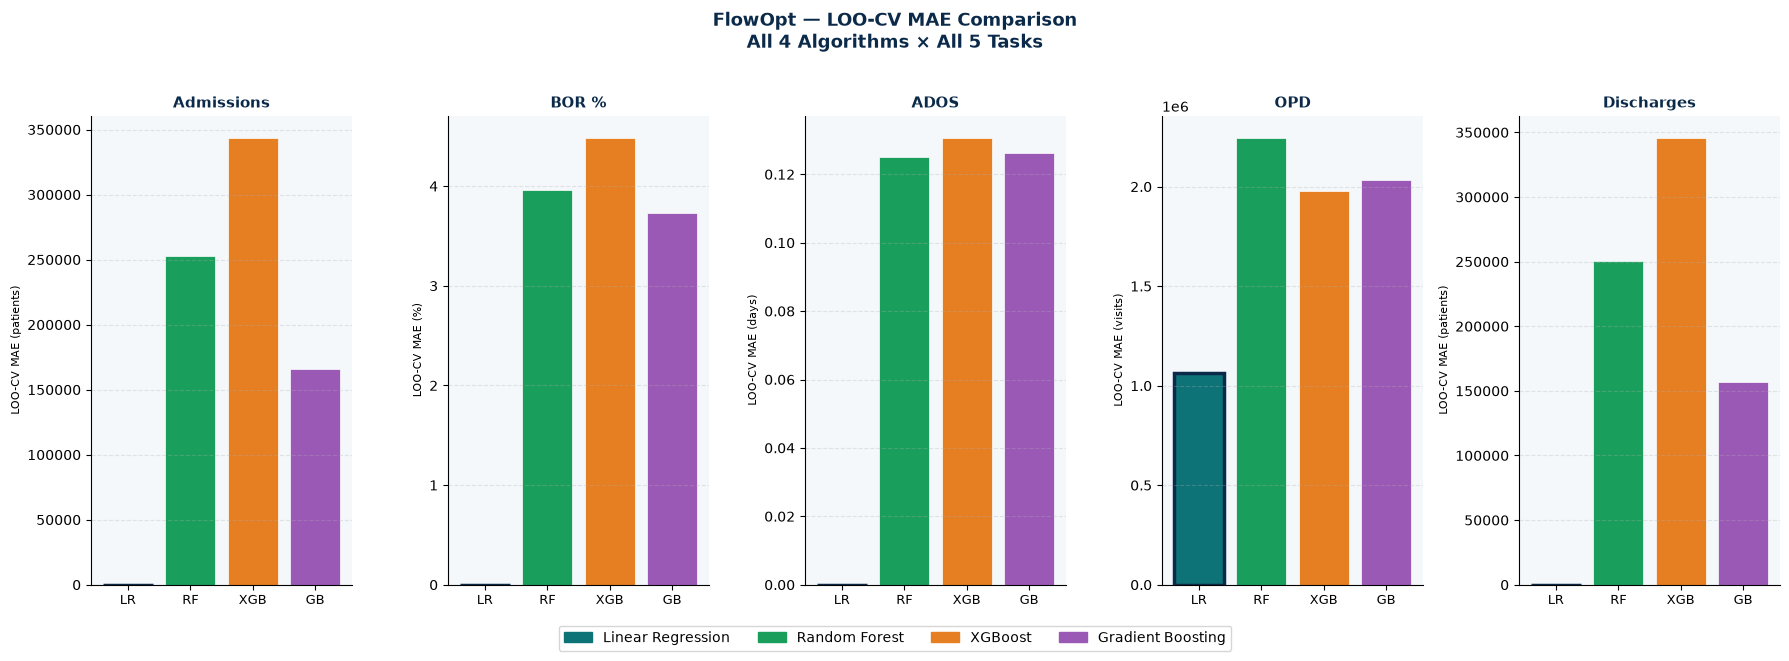

✅ Figure 1 saved:
  C:/Users/MSI/flowopt\data\processed\fig1_model_comparison.png


In [7]:
fig, axes = plt.subplots(
    1, 5, figsize=(18, 6))
fig.suptitle(
    'FlowOpt — LOO-CV MAE Comparison\n'
    'All 4 Algorithms × All 5 Tasks',
    fontsize=13,
    fontweight='bold',
    color=COLORS['navy'],
    y=1.02)

task_labels = [
    'Admissions', 'BOR %',
    'ADOS', 'OPD', 'Discharges',
]
units = [
    'patients','%',
    'days','visits','patients',
]
bar_colors = [
    COLORS['teal'],
    COLORS['green'],
    COLORS['orange'],
    COLORS['purple'],
]

for ax, task, r, unit in zip(
        axes, task_labels,
        results_list, units):
    maes = [get_mae(r, a) for a in algos]
    bars = ax.bar(
        range(4), maes,
        color=bar_colors,
        edgecolor='white',
        linewidth=0.5)
    # Highlight best
    min_i = maes.index(min(maes))
    bars[min_i].set_edgecolor(
        COLORS['navy'])
    bars[min_i].set_linewidth(2.5)

    ax.set_title(
        task,
        fontweight='bold',
        color=COLORS['navy'],
        fontsize=11)
    ax.set_ylabel(
        f'LOO-CV MAE ({unit})',
        fontsize=8)
    ax.set_xticks(range(4))
    ax.set_xticklabels(
        ['LR','RF','XGB','GB'],
        fontsize=9)
    ax.set_facecolor(COLORS['light'])
    ax.grid(axis='y',
        alpha=0.3, linestyle='--')

legend_handles = [
    mpatches.Patch(
        color=bar_colors[i],
        label=algos[i])
    for i in range(4)]
fig.legend(
    handles=legend_handles,
    loc='lower center', ncol=4,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
save_path = os.path.join(
    PROCESSED,
    'fig1_model_comparison.png')
plt.savefig(save_path, dpi=150,
    bbox_inches='tight',
    facecolor='white')
plt.show()
print(f"✅ Figure 1 saved:\n  {save_path}")

In [8]:
final_data = [
    (X_adm,  y_adm,
     'Total Inpatient Admissions',
     'patients'),
    (X_bor,  y_bor,
     'Bed Occupancy Rate',
     '%'),
    (X_ados, y_ados,
     'Avg Length of Stay',
     'days'),
    (X_opd,  y_opd,
     'OPD Attendance',
     'visits'),
    (X_disc, y_disc,
     'Discharge Volume',
     'patients'),
]

final_rows = []
loo = LeaveOneOut()

print("Final Model Performance Summary")
print("Algorithm: Linear Regression")
print("="*60)

for X, y, task, unit in final_data:
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)

    full_mae  = mean_absolute_error(
        y, y_pred)
    full_rmse = np.sqrt(
        mean_squared_error(y, y_pred))
    full_r2   = r2_score(y, y_pred)

    loo_mae = -cross_val_score(
        LinearRegression(),
        X, y, cv=loo,
        scoring=
            'neg_mean_absolute_error'
    ).mean()

    final_rows.append({
        'Task':       task,
        'Full MAE':   round(full_mae, 4),
        'Full RMSE':  round(full_rmse, 4),
        'Full R²':    round(full_r2, 4),
        'LOO-CV MAE': round(loo_mae, 4),
    })

    print(f"\n{task}")
    print(f"  Full R²:    {full_r2:.4f}")
    print(f"  Full MAE:   {full_mae:.4f}"
          f" {unit}")
    print(f"  LOO-CV MAE: {loo_mae:.4f}"
          f" {unit}")

df_final = pd.DataFrame(final_rows)
print("\n" + "="*60)
print("\nTABLE 2 — Final Model Summary")
print(df_final[[
    'Task','Full R²',
    'Full MAE','LOO-CV MAE']
].to_string(index=False))

Final Model Performance Summary
Algorithm: Linear Regression

Total Inpatient Admissions
  Full R²:    1.0000
  Full MAE:   0.0001 patients
  LOO-CV MAE: 0.0002 patients

Bed Occupancy Rate
  Full R²:    1.0000
  Full MAE:   0.0000 %
  LOO-CV MAE: 0.0000 %

Avg Length of Stay
  Full R²:    1.0000
  Full MAE:   0.0000 days
  LOO-CV MAE: 0.0000 days

OPD Attendance
  Full R²:    0.9988
  Full MAE:   96132.7533 visits
  LOO-CV MAE: 1062809.7486 visits

Discharge Volume
  Full R²:    1.0000
  Full MAE:   0.0001 patients
  LOO-CV MAE: 0.0002 patients


TABLE 2 — Final Model Summary
                      Task  Full R²   Full MAE   LOO-CV MAE
Total Inpatient Admissions   1.0000     0.0001       0.0002
        Bed Occupancy Rate   1.0000     0.0000       0.0000
        Avg Length of Stay   1.0000     0.0000       0.0000
            OPD Attendance   0.9988 96132.7533 1062809.7486
          Discharge Volume   1.0000     0.0001       0.0002


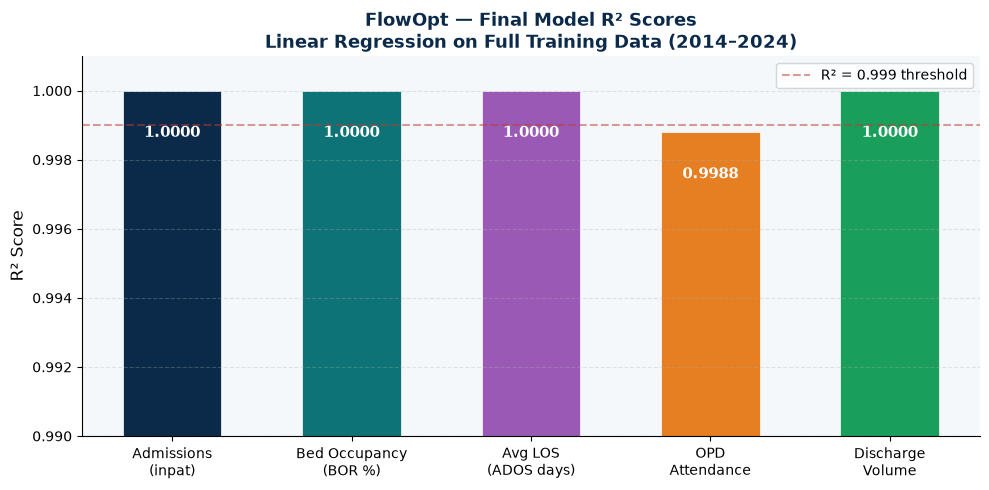

✅ Figure 2 saved:
  C:/Users/MSI/flowopt\data\processed\fig2_r2_scores.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

task_short = [
    'Admissions\n(inpat)',
    'Bed Occupancy\n(BOR %)',
    'Avg LOS\n(ADOS days)',
    'OPD\nAttendance',
    'Discharge\nVolume',
]
r2_vals = df_final['Full R²'].tolist()
t_colors = [
    COLORS['navy'],   COLORS['teal'],
    COLORS['purple'], COLORS['orange'],
    COLORS['green'],
]

bars = ax.bar(
    task_short, r2_vals,
    color=t_colors,
    edgecolor='white',
    linewidth=0.5, width=0.55)

for bar, val in zip(bars, r2_vals):
    ax.text(
        bar.get_x()
            + bar.get_width()/2,
        bar.get_height() - 0.001,
        f'{val:.4f}',
        ha='center', va='top',
        fontsize=11,
        fontweight='bold',
        color='white')

ax.set_ylim(0.990, 1.001)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title(
    'FlowOpt — Final Model R² Scores\n'
    'Linear Regression on Full '
    'Training Data (2014–2024)',
    fontsize=13,
    fontweight='bold',
    color=COLORS['navy'])
ax.set_facecolor(COLORS['light'])
ax.grid(axis='y',
    alpha=0.3, linestyle='--')
ax.axhline(y=0.999,
    color=COLORS['red'],
    linestyle='--', alpha=0.5,
    label='R² = 0.999 threshold')
ax.legend(fontsize=10)

plt.tight_layout()
save_path = os.path.join(
    PROCESSED,
    'fig2_r2_scores.png')
plt.savefig(save_path, dpi=150,
    bbox_inches='tight',
    facecolor='white')
plt.show()
print(f"✅ Figure 2 saved:\n  {save_path}")

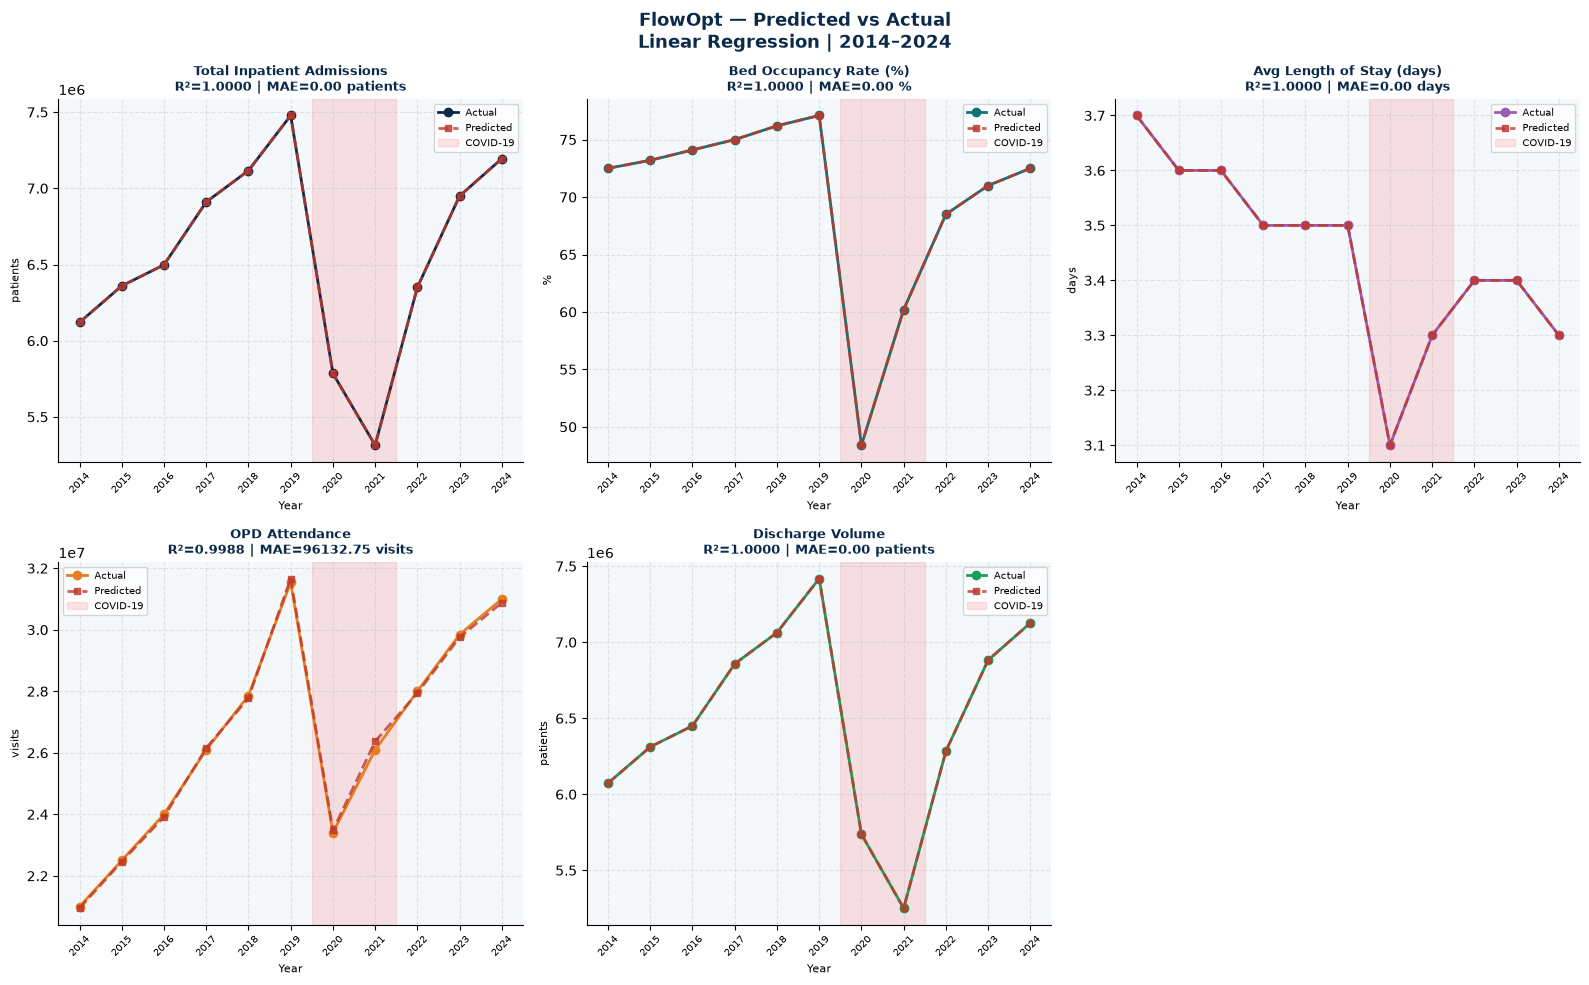

✅ Figure 3 saved:
  C:/Users/MSI/flowopt\data\processed\fig3_predicted_vs_actual.png


In [10]:
tasks_plot = [
    (X_adm,  y_adm,  years_adm,
     'Total Inpatient Admissions',
     COLORS['navy'],   'patients'),
    (X_bor,  y_bor,  years_bor,
     'Bed Occupancy Rate (%)',
     COLORS['teal'],   '%'),
    (X_ados, y_ados, years_ados,
     'Avg Length of Stay (days)',
     COLORS['purple'], 'days'),
    (X_opd,  y_opd,  years_opd,
     'OPD Attendance',
     COLORS['orange'], 'visits'),
    (X_disc, y_disc, years_disc,
     'Discharge Volume',
     COLORS['green'],  'patients'),
]

fig, axes = plt.subplots(
    2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (X, y, years,
        task, color, unit) in enumerate(
        tasks_plot):
    ax = axes[i]
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)

    ax.plot(years, y.values,
        'o-', color=color,
        linewidth=2, markersize=6,
        label='Actual', zorder=3)
    ax.plot(years, y_pred,
        's--',
        color=COLORS['red'],
        linewidth=2, markersize=5,
        alpha=0.8,
        label='Predicted', zorder=3)
    ax.axvspan(
        2019.5, 2021.5,
        alpha=0.1, color='red',
        label='COVID-19')

    r2  = r2_score(y, y_pred)
    mae = mean_absolute_error(
        y, y_pred)

    ax.set_title(
        f'{task}\n'
        f'R²={r2:.4f} | '
        f'MAE={mae:.2f} {unit}',
        fontsize=9,
        fontweight='bold',
        color=COLORS['navy'])
    ax.set_xlabel('Year', fontsize=8)
    ax.set_ylabel(unit, fontsize=8)
    ax.legend(fontsize=7)
    ax.set_facecolor(COLORS['light'])
    ax.grid(alpha=0.3, linestyle='--')
    ax.set_xticks(years)
    ax.set_xticklabels(
        years, rotation=45, fontsize=7)

axes[5].set_visible(False)

fig.suptitle(
    'FlowOpt — Predicted vs Actual\n'
    'Linear Regression | 2014–2024',
    fontsize=13,
    fontweight='bold',
    color=COLORS['navy'])

plt.tight_layout()
save_path = os.path.join(
    PROCESSED,
    'fig3_predicted_vs_actual.png')
plt.savefig(save_path, dpi=150,
    bbox_inches='tight',
    facecolor='white')
plt.show()
print(f"✅ Figure 3 saved:\n  {save_path}")

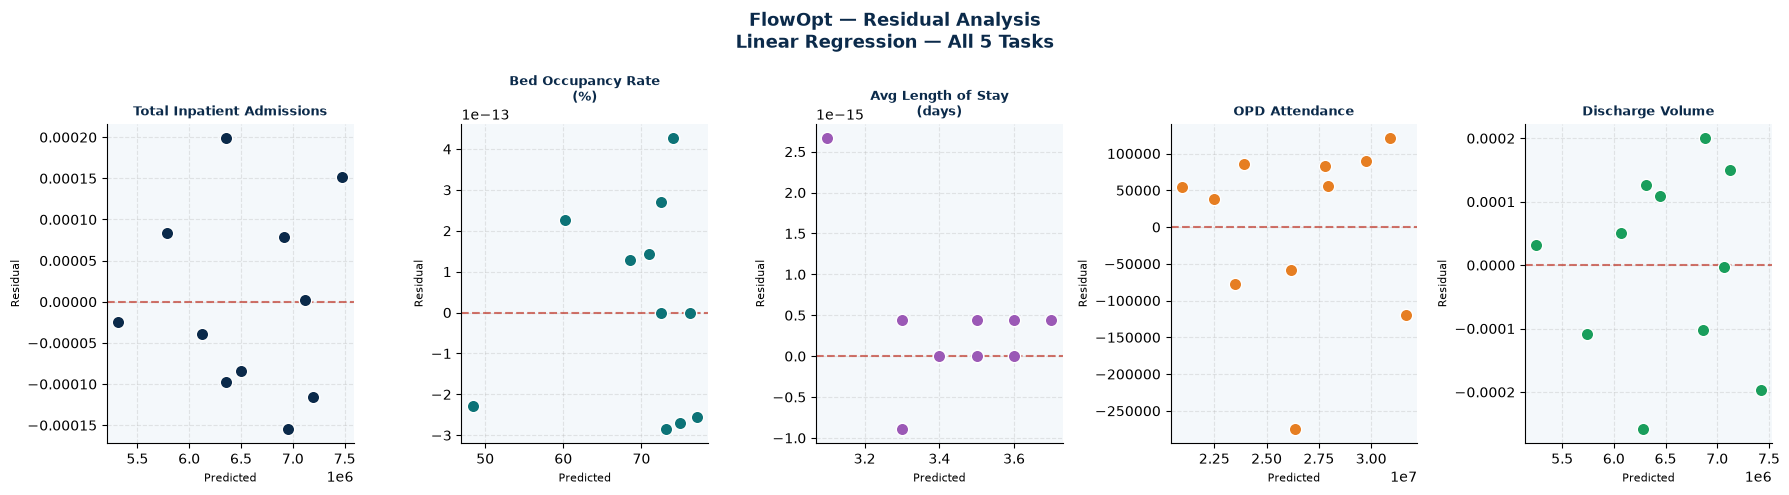

✅ Figure 4 saved:
  C:/Users/MSI/flowopt\data\processed\fig4_residual_analysis.png


In [11]:
fig, axes = plt.subplots(
    1, 5, figsize=(18, 5))
fig.suptitle(
    'FlowOpt — Residual Analysis\n'
    'Linear Regression — All 5 Tasks',
    fontsize=13,
    fontweight='bold',
    color=COLORS['navy'])

t_colors = [
    COLORS['navy'],   COLORS['teal'],
    COLORS['purple'], COLORS['orange'],
    COLORS['green'],
]

for i, (ax, (X, y, years,
        task, color, unit)) in enumerate(
        zip(axes, tasks_plot)):
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    residuals = y.values - y_pred

    ax.scatter(
        y_pred, residuals,
        color=t_colors[i],
        edgecolor='white',
        s=80, zorder=3)
    ax.axhline(
        y=0,
        color=COLORS['red'],
        linestyle='--',
        linewidth=1.5, alpha=0.7)

    ax.set_title(
        task.replace(' (','\n('),
        fontsize=9,
        fontweight='bold',
        color=COLORS['navy'])
    ax.set_xlabel(
        'Predicted', fontsize=8)
    ax.set_ylabel(
        'Residual', fontsize=8)
    ax.set_facecolor(COLORS['light'])
    ax.grid(
        alpha=0.3, linestyle='--')

plt.tight_layout()
save_path = os.path.join(
    PROCESSED,
    'fig4_residual_analysis.png')
plt.savefig(save_path, dpi=150,
    bbox_inches='tight',
    facecolor='white')
plt.show()
print(f"✅ Figure 4 saved:\n  {save_path}")

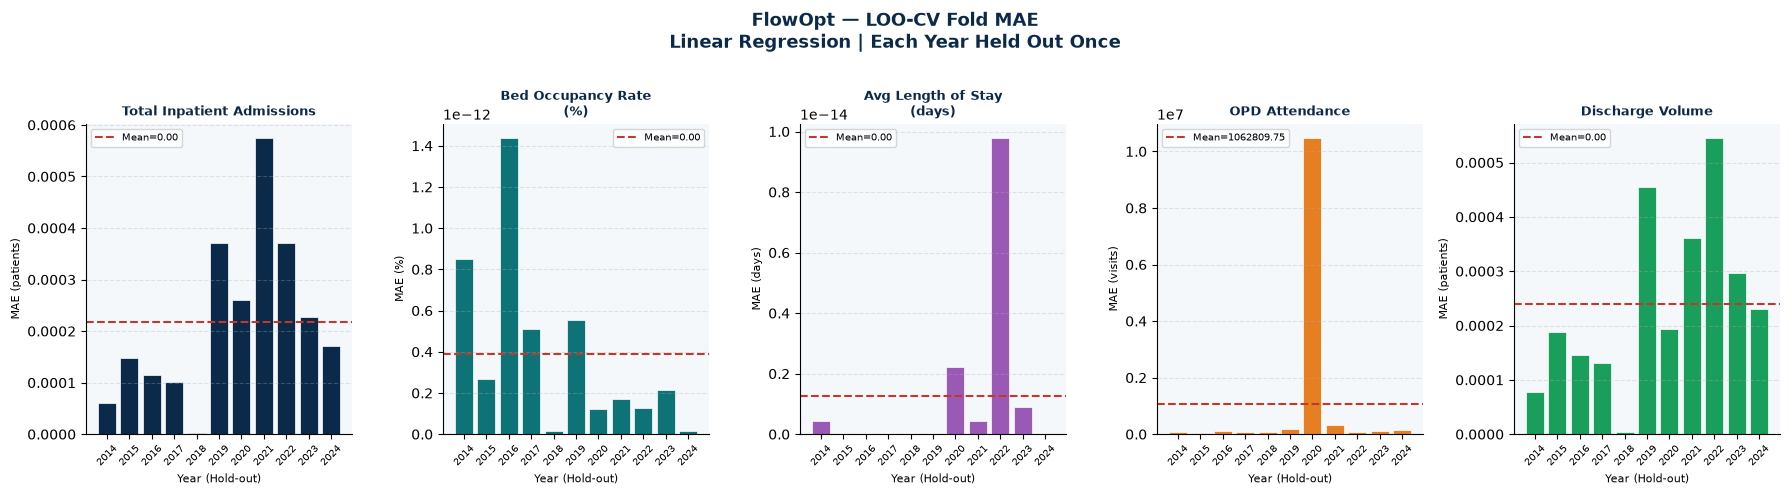

✅ Figure 5 saved:
  C:/Users/MSI/flowopt\data\processed\fig5_loocv_fold_mae.png


In [12]:
fig, axes = plt.subplots(
    1, 5, figsize=(18, 5))
fig.suptitle(
    'FlowOpt — LOO-CV Fold MAE\n'
    'Linear Regression | Each Year '
    'Held Out Once',
    fontsize=13,
    fontweight='bold',
    color=COLORS['navy'])

for i, (ax, (X, y, years,
        task, color, unit)) in enumerate(
        zip(axes, tasks_plot)):
    loo = LeaveOneOut()
    fold_maes = []

    for train_i, test_i in loo.split(X):
        X_tr = X.iloc[train_i]
        y_tr = y.iloc[train_i]
        X_te = X.iloc[test_i]
        y_te = y.iloc[test_i]

        m = LinearRegression()
        m.fit(X_tr, y_tr)
        pred = m.predict(X_te)
        fold_maes.append(
            abs(y_te.values[0]
                - pred[0]))

    ax.bar(years, fold_maes,
        color=t_colors[i],
        edgecolor='white',
        linewidth=0.5)
    ax.axhline(
        y=np.mean(fold_maes),
        color=COLORS['red'],
        linestyle='--',
        linewidth=1.5,
        label=f'Mean='
              f'{np.mean(fold_maes):.2f}')

    ax.set_title(
        task.replace(' (','\n('),
        fontsize=9,
        fontweight='bold',
        color=COLORS['navy'])
    ax.set_xlabel(
        'Year (Hold-out)',
        fontsize=8)
    ax.set_ylabel(
        f'MAE ({unit})', fontsize=8)
    ax.legend(fontsize=7)
    ax.set_facecolor(COLORS['light'])
    ax.grid(axis='y',
        alpha=0.3, linestyle='--')
    ax.set_xticks(years)
    ax.set_xticklabels(
        years, rotation=45, fontsize=7)

plt.tight_layout()
save_path = os.path.join(
    PROCESSED,
    'fig5_loocv_fold_mae.png')
plt.savefig(save_path, dpi=150,
    bbox_inches='tight',
    facecolor='white')
plt.show()
print(f"✅ Figure 5 saved:\n  {save_path}")

In [13]:
print("Verifying saved model files...")
print("="*50)

model_files = [
    'admission_model.pkl',
    'bed_model.pkl',
    'los_model.pkl',
    'opd_model.pkl',
    'discharge_model.pkl',
]

all_ok = True
for fname in model_files:
    fpath = os.path.join(MODELS, fname)
    if os.path.exists(fpath):
        m = joblib.load(fpath)
        size = os.path.getsize(fpath)
        print(f"✅ {fname}")
        print(f"   Type: "
              f"{type(m).__name__}")
        print(f"   Size: {size} bytes")
    else:
        print(f"❌ {fname} NOT FOUND")
        all_ok = False

print("="*50)
if all_ok:
    print("✅ All 5 models verified!")
else:
    print("⚠️ Run 03_Model_Training"
          ".ipynb first")

Verifying saved model files...
✅ admission_model.pkl
   Type: LinearRegression
   Size: 993 bytes
✅ bed_model.pkl
   Type: LinearRegression
   Size: 929 bytes
✅ los_model.pkl
   Type: LinearRegression
   Size: 929 bytes
✅ opd_model.pkl
   Type: LinearRegression
   Size: 881 bytes
✅ discharge_model.pkl
   Type: LinearRegression
   Size: 993 bytes
✅ All 5 models verified!


In [14]:
df_final.to_csv(
    os.path.join(
        PROCESSED,
        'flowopt_validation_summary.csv'),
    index=False)

print("✅ Validation summary saved!")
print()
print(df_final[[
    'Task','Full R²',
    'Full MAE','LOO-CV MAE'
]].to_string(index=False))
print()
print("="*55)
print("Figures saved to data/processed/:")
figs = [
    'fig1_model_comparison.png',
    'fig2_r2_scores.png',
    'fig3_predicted_vs_actual.png',
    'fig4_residual_analysis.png',
    'fig5_loocv_fold_mae.png',
    'flowopt_validation_summary.csv',
]
for f in figs:
    fpath = os.path.join(PROCESSED, f)
    exists = os.path.exists(fpath)
    status = "✅" if exists else "❌"
    print(f"  {status} {f}")
print()
print("="*55)
print("✅ 05_Validation.ipynb COMPLETE!")
print("="*55)

✅ Validation summary saved!

                      Task  Full R²   Full MAE   LOO-CV MAE
Total Inpatient Admissions   1.0000     0.0001       0.0002
        Bed Occupancy Rate   1.0000     0.0000       0.0000
        Avg Length of Stay   1.0000     0.0000       0.0000
            OPD Attendance   0.9988 96132.7533 1062809.7486
          Discharge Volume   1.0000     0.0001       0.0002

Figures saved to data/processed/:
  ✅ fig1_model_comparison.png
  ✅ fig2_r2_scores.png
  ✅ fig3_predicted_vs_actual.png
  ✅ fig4_residual_analysis.png
  ✅ fig5_loocv_fold_mae.png
  ✅ flowopt_validation_summary.csv

✅ 05_Validation.ipynb COMPLETE!
